In [1]:
import os
import sys
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
from PIL import Image
from glob import glob
from tools.fdm.src import fdm3Blom, mfgrid
from tools.etc import color_cycler, logo, descr, pickleto, picklefrom
from importlib import reload

print("=== Current Session ===")
print("os.getcwd():", os.getcwd())
print("sys.executable: ", sys.executable)
print("sys.path:")
for p in sys.path:
    print(p)
print("=======================")


NOTEBOOK_NAME = "explore_data.ipynb"
print(f"NOTEBOOK_NAME = '{NOTEBOOK_NAME}'")

# --- project directory namespace
class Dirs:
    def __init__(self):
        self.rws = "/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/"
        self.home   = os.path.join(self.rws, "src")
        self.images = os.path.normpath(os.path.join(self.home, '../images'))
        self.data   = os.path.normpath(os.path.join(self.home, '../data'))
        self.pb_data = os.path.normpath(os.path.join(self.data, 'peilbuizen'))
        self.pb_imag = os.path.normpath(os.path.join(self.images, 'peilbuizen'))
        
dirs = Dirs()

# --- dtypes for boundary conditions of Fdm3
dtypes = fdm3Blom.Fdm3.dtypes

print("Project directory namespace:")
descr(dirs)

loading mfpath.py

os.getcwd(): /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/notebooks
sys.executable =  /Users/Theo/Development/python/mf6_tools/mf6lab/.venv/bin/python
ARGV ['/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/ipykernel_launcher.py', '--f=/Users/Theo/Library/Jupyter/runtime/kernel-v3c2870303958825b004e17ff6b889c1cbbef1b9fb.json']
sys.path:
/Users/Theo/GRWMODELS/python/tools
./modules/
/Users/Theo/GRWMODELS/python/bootstraps
/Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload

/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages
__editable__.mf6lab-0.1.finder.__path_hook__
__editable__.tools-0.1.finder.__path_hook__

=== Current Session ===
os.getcwd(): /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/notebooks
sys

In [2]:
class Peilbuizen():
    def __init__(self, workbook_name, sheet_name=None):
        self.data = pd.read_excel(os.path.join(dirs.pb_imag, workbook_name), sheet_name=sheet_name, index_col='name')
        
    def plot(self, ax, **kwargs):
        """Plot all observation well locations at once."""
        ax.plot(self.data['x'], self.data['y'], 'o', **kwargs)
        
    def put_raai_names(self, ax, xoffset=100., verbose=False, **kwargs):
        """Put the piezometer row names to the right of the last in the row + xoffset."""
        rows = np.arange(100, 1500, 100)
        for r1, r2 in zip(rows[:-1], rows[1:]):
            y = pbxy.data.loc[np.logical_and(pbxy.data.index >= r1, pbxy.data.index < r2), 'y'].mean().round()
            x = pbxy.data.loc[np.logical_and(pbxy.data.index >= r1, pbxy.data.index < r2), 'x'].values[-1].round() + xoffset
            ax.text(x, y, f'raai{r1/100:.0f}', **kwargs)
            if verbose:
                print(f"raai{r1/100:.0f}, x={x:.0f}, y={y:.0f}") 


# --- Example:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')

# --- Plot the data (could be on a map).
# fig, ax = plt.subplots(figsize=(8, 12))
# pbxy.plot(ax, mec='r', mfc='none', ms=6)
# pbxy.put_raai_names(ax, ha='left', va='center')
# ax.plot(ARK_center_line_GE[:,0], ARK_center_line_GE[:,1], 'b', label='ARK-hartlijn')
# ax.set_aspect(1)
# 
# plt.show()


In [4]:
def point_line_distance(P, A, B):
    """
    Distance from points P to infinite line through A and B.

    Parameters
    ----------
    P : (..., 2) array_like
        One or more points.
    A, B : (2,) array_like
        Two points defining the line.

    Returns
    -------
    d : ndarray
        Distances.
    """

    P = np.asarray(P)
    A = np.asarray(A)
    B = np.asarray(B)

    AB = B - A
    AP = P - A

    cross = AB[0] * AP[..., 1] - AB[1] * AP[..., 0]

    return np.round(np.abs(cross) / np.linalg.norm(AB), 2), np.sign(cross)




def point_segment_distance(P, A, B):
    P = np.asarray(P)
    A = np.asarray(A)
    B = np.asarray(B)

    AB = B - A
    AP = P - A

    L2 = np.dot(AB, AB)

    t = np.sum(AP * AB, axis=-1) / L2
    t = np.clip(t, 0.0, 1.0)

    Q = A + t[..., None] * AB

    return np.linalg.norm(P - Q, axis=-1)


def point_polyline_distance(P, polyline):
    """
    Distance from points P to a polyline.

    Parameters
    ----------
    P : (..., 2) array
        One or more points.
    polyline : (n, 2) array
        Vertices of the polyline.

    Returns
    -------
    dmin : (...)
        Minimum distance.
    Qmin : (..., 2)
        Closest points on the polyline.
    """

    P = np.asarray(P)
    polyline = np.asarray(polyline)

    dmin = np.inf * np.ones(P.shape[:-1])
    Qmin = np.zeros(P.shape)

    for A, B in zip(polyline[:-1], polyline[1:]):

        AB = B - A
        AP = P - A

        L2 = np.dot(AB, AB)

        t = np.sum(AP * AB, axis=-1) / L2
        t = np.clip(t, 0.0, 1.0)

        Q = A + t[..., None] * AB

        d = np.linalg.norm(P - Q, axis=-1)

        mask = d < dmin

        dmin[mask] = d[mask]
        Qmin[mask] = Q[mask]

    return dmin, Qmin

In [5]:
hartlijn_ARK = np.array([
    [130051., 479494.],
    [130051., 479403.],
    [130058., 479291.],
    [130057., 478773.],
    [130059., 478204.],
    [130062., 477929.],
    [130060., 477296.],
    [130055., 477008.],
    [129934., 476382.],
    [129903., 476242.],
    [129650., 474744.],
    [129499., 473872.],
    [129386., 473219.],
    [129272., 472556.],
    [129131., 471746.],
    [129024., 471122.],
    [128914., 470499.],
    [128849., 470129.],
    [128714., 469312.],
    [128630., 468844.],
    [128550., 468382.],
    [128439., 467731.],
    [128314., 467022.],
    [128226., 466501.],
    [128136., 465900.]])

# Plot the piezometers on the maps to show their positions in context

In [ ]:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pxy = np.asarray(pbxy.data.loc[:, ['x', 'y']])

In [ ]:
maps = [os.path.basename(p) for p in glob(os.path.join(dirs.pb_imag, 'map*.png'))]
maps

# Observation well locations on map

In [ ]:

fig, ax = plt.subplots(figsize=(8,12))

im = 0

extent = list(map(float, re.findall(r'\d+', maps[im])))

img = Image.open(os.path.join(dirs.pb_imag, maps[im]))
ax.imshow(img, extent=extent, origin='upper')

pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')

pbxy.plot(ax, mec='r', mfc='none', ms=2)
pbxy.put_raai_names(ax, ha='left', va='center')
ax.plot(hartlijn_ARK[:,0], hartlijn_ARK[:,1], 'b', label='ARK-hartlijn')
ax.set_aspect(1)

ax.set_title(f"File: '{maps[im]}'", fontsize=10)
ax.legend()

for pb in pbxy.data.index:
    rec = pbxy.data.loc[pb]
    ax.plot([rec['x'], rec['xhit']], [rec['y'], rec['yhit']], 'k')
    


logo(fig, NOTEBOOK_NAME)
if im == 0:
    fig.savefig(os.path.join(dirs.images, "peilgeb_pb"))
if im == 2:
    fig.savefig(os.path.join(dirs.images, "ligging_dsn_Deltares"))


# Grondwaterstanden

Verkregen webplotdigitizer vanaf de figuren in Deltares rapport "Systeemanalyze, concept maart 2026".

In [ ]:
temp_ark = pd.read_csv(os.path.join(dirs.pb_data, 'tempARK_maarssen.csv'), index_col=0, parse_dates=True)
temp_ark.columns = ['temp']
temp_ark.index.name = 'datetime'
temp_ark

fig, ax = plt.subplots()
ax.plot(temp_ark.index, temp_ark['temp'])
ax.set_ylabel("temperatuur ARK kanaal")
ax.set_title("Temperatuur ARK kanaal in Maarssen")
ax.grid()


# Plot heads en temperatures of all rows (as far as as data is available)

/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a,

Month-averaged head around the 3 dates given min, max and min values
pb1,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.322
pb2,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.376
pb3,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.144
pb4,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.403
pb5,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.382
pb6,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.502
pb7,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.489
pb8,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.565
pb9,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.481
pb10,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.559
pb101,2025-01-25,2025-08-01,2026-02-01,nan,-1.692,-1.78
pb102,2025-01-25,2025-08-01,2026-02-01,nan,-1.739,-1.841
pb201,2025-01-25,2025-08-01,2026-02-01,nan,-1.481,-1.684
pb202,2025-01-25,2025-08-01,2026-02-01,nan,-1.49,-1.7
pb301,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.654
pb302,2025-01-25,2025-08-01,2026-02-01,nan,-1.235,-1.556
pb303,2025-01-25,2025-08-01,2026-02-01,nan,-1.116,nan
pb304,2025-01-25,2025

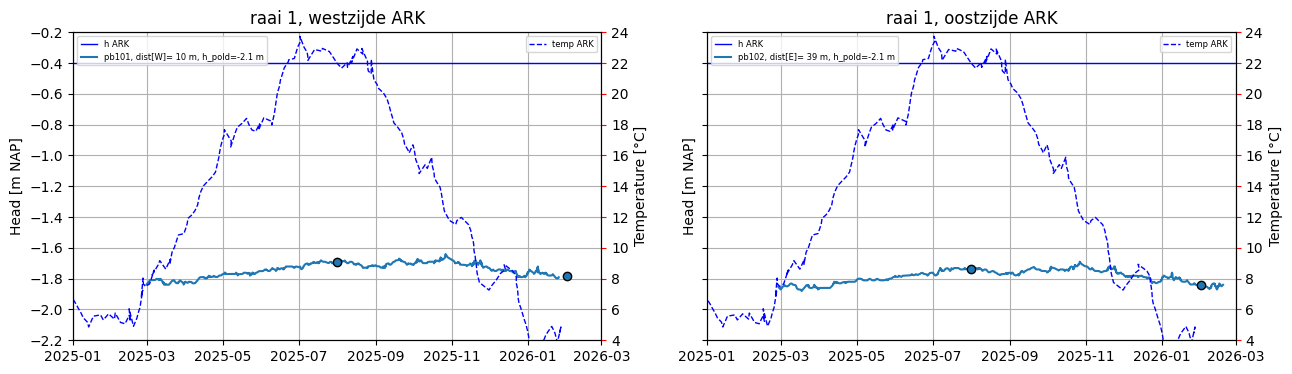

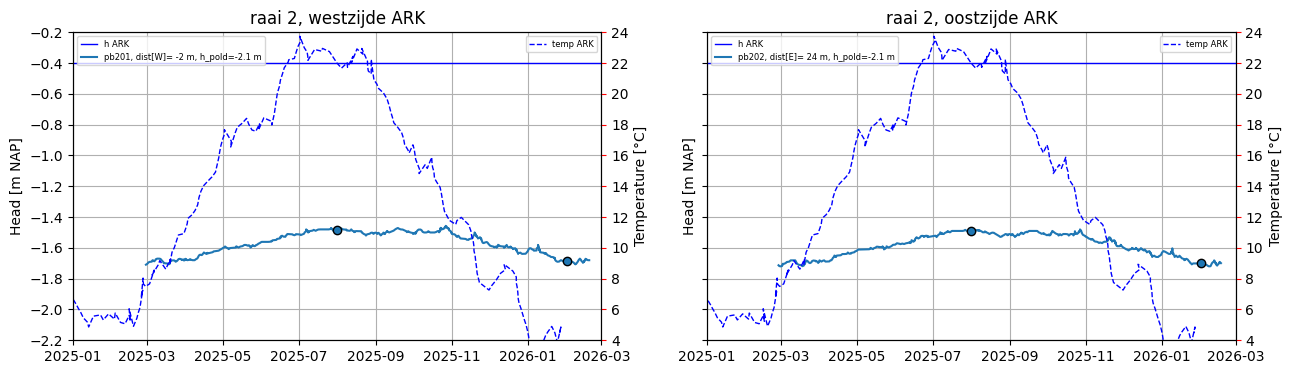

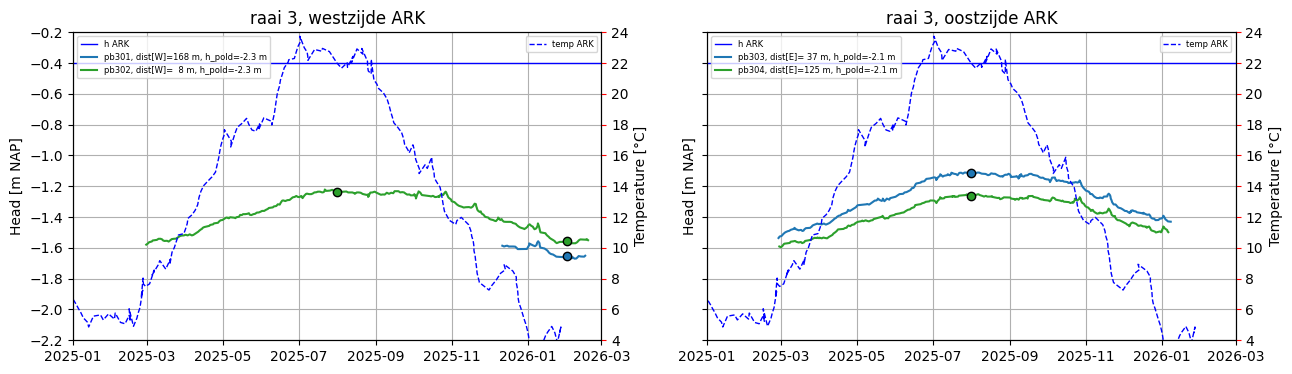

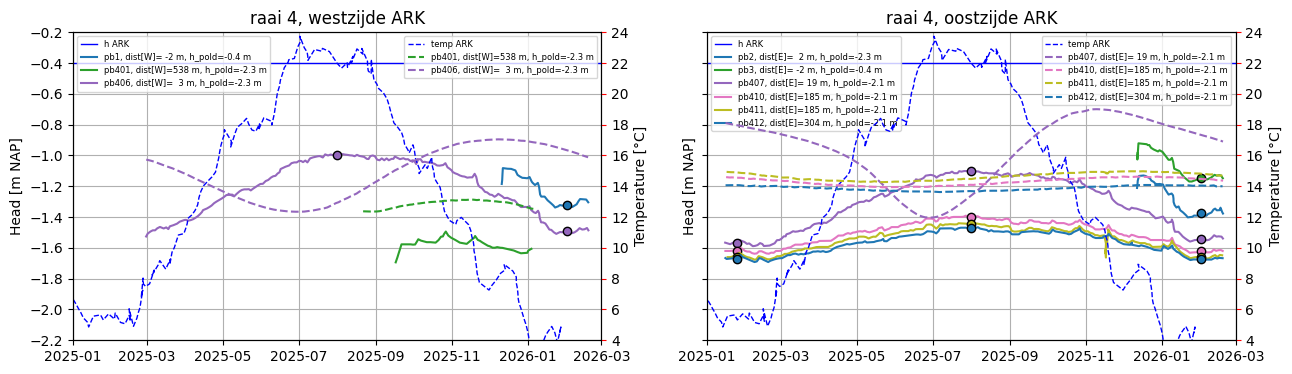

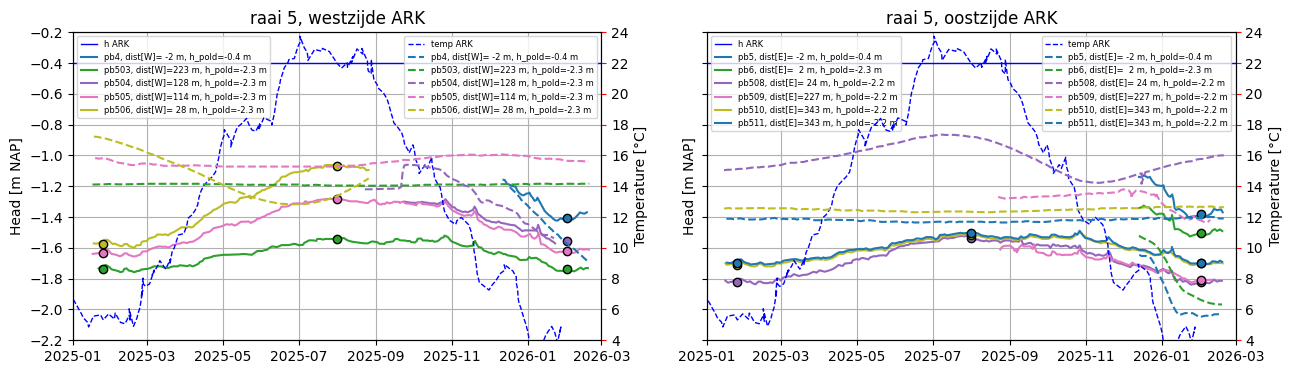

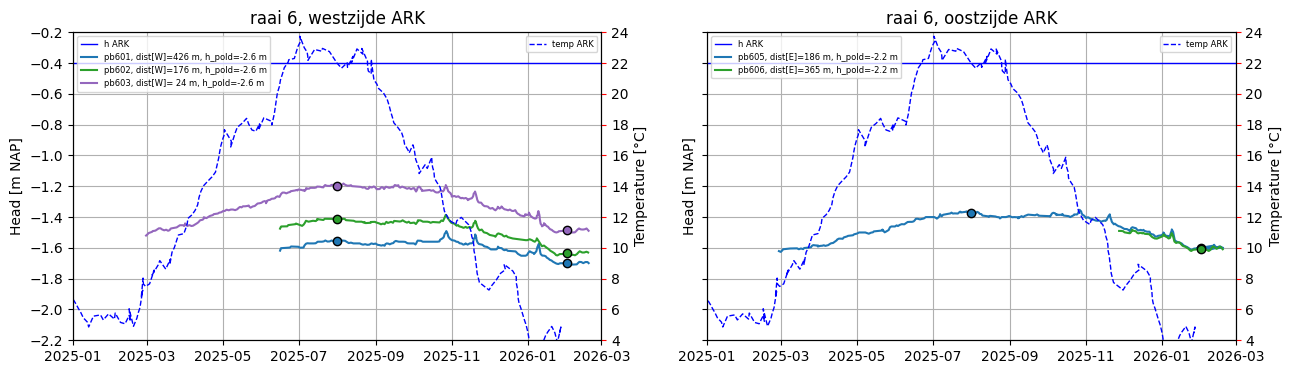

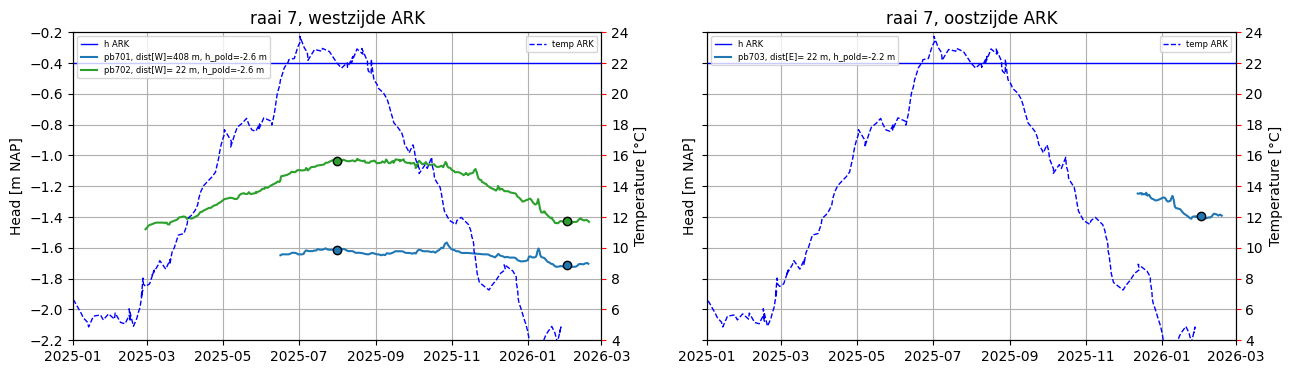

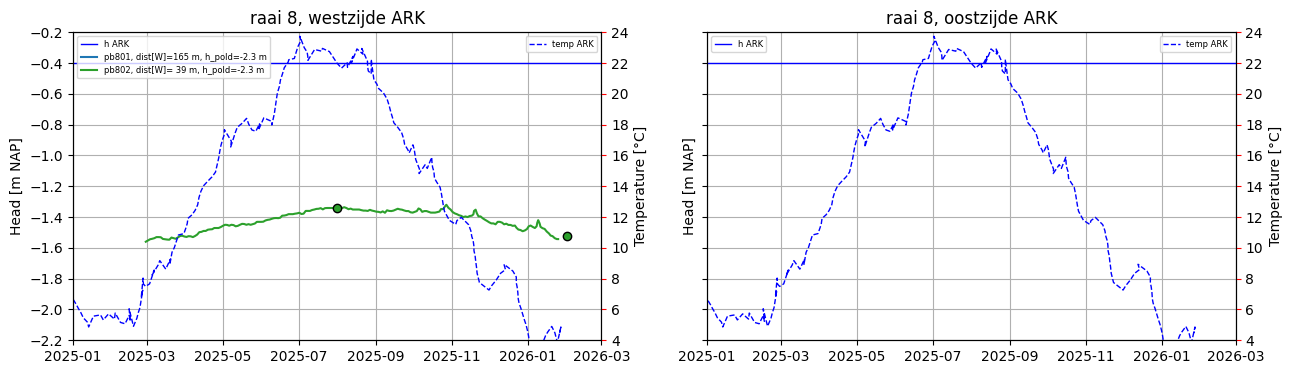

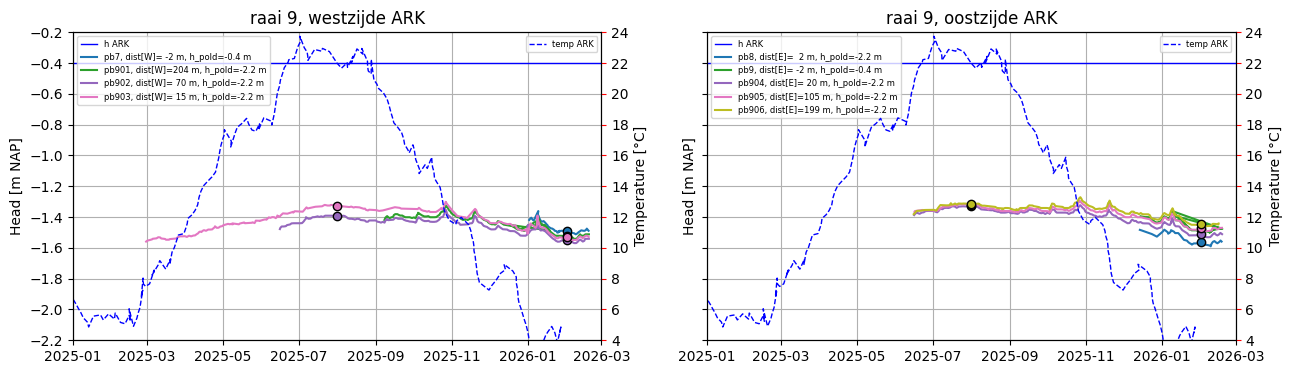

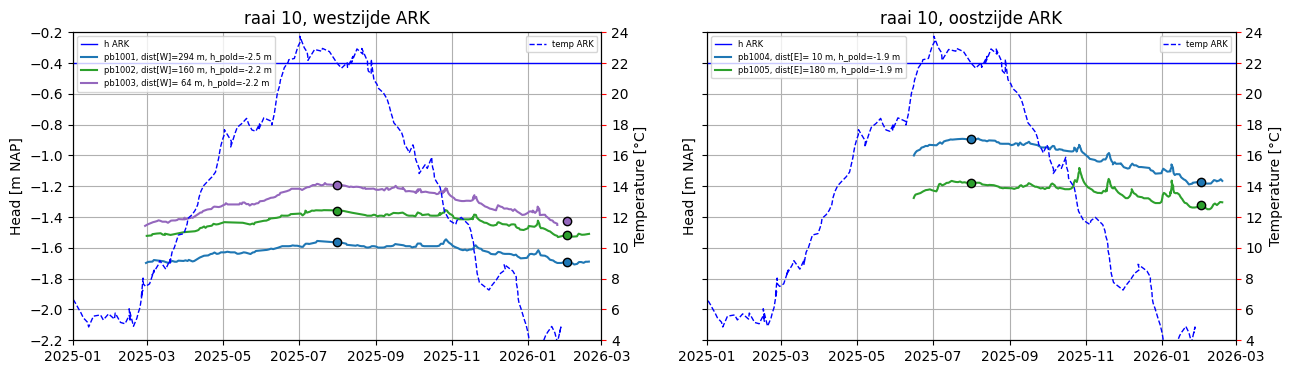

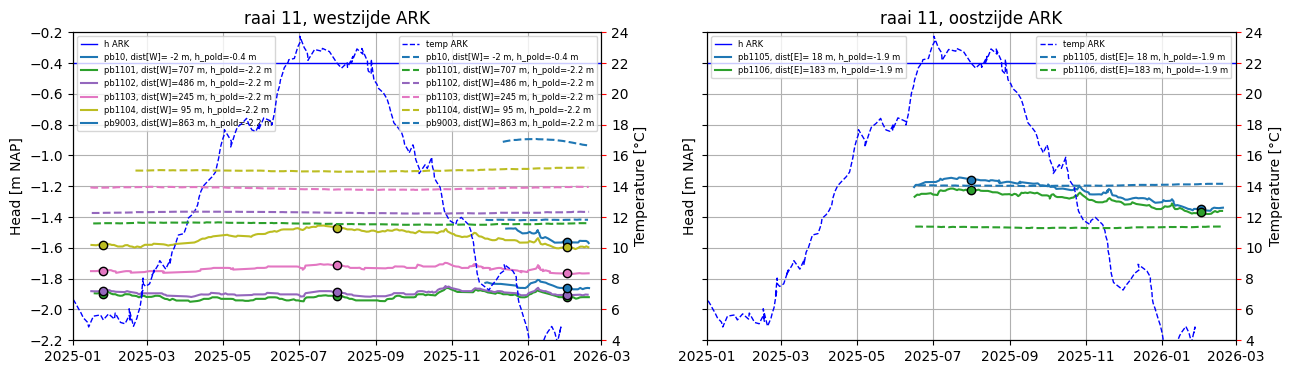

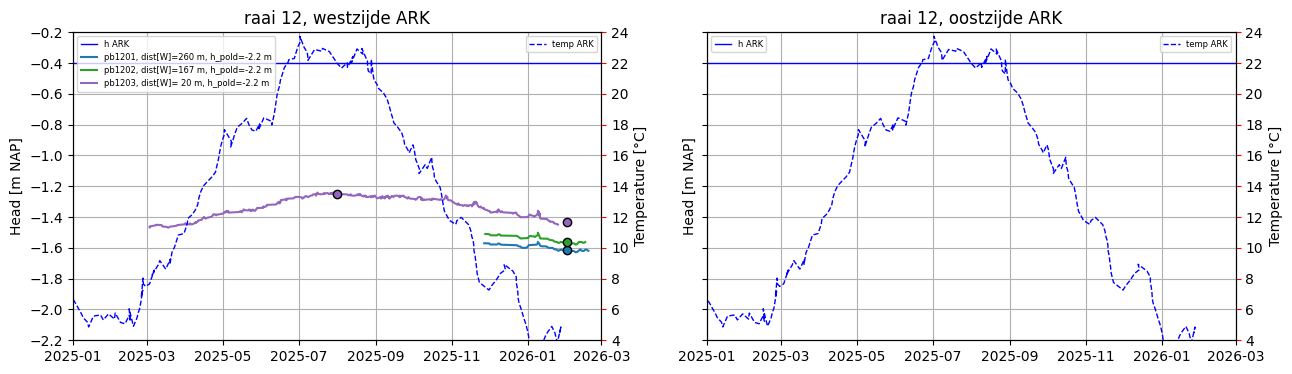

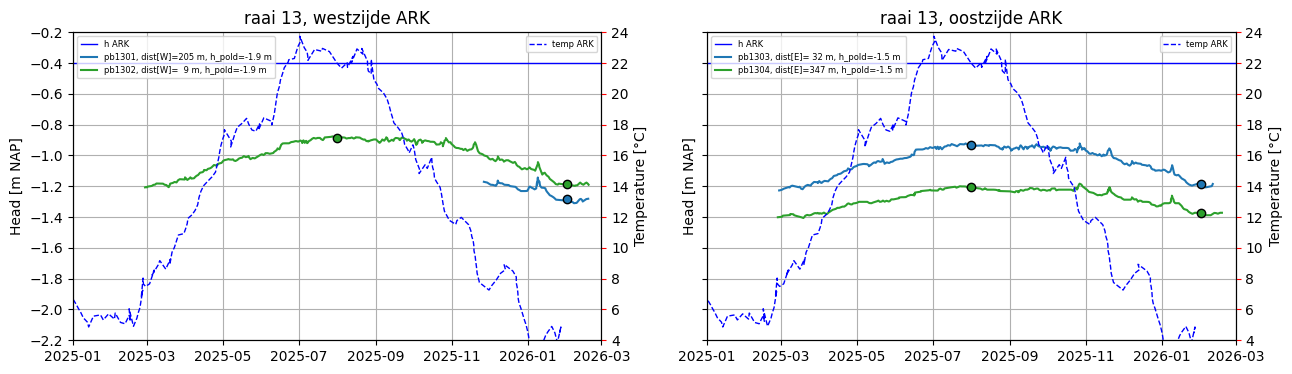

In [13]:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pbkan = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbKanaal')

# --- pd.DataFrame
pb_tauw_meta   = pbxy.data
pb_kanaal_meta = pbkan.data

b_ARK = 50

# --- Get ARK temperature
temp_ark = pd.read_csv(os.path.join(dirs.pb_data, 'tempARK_maarssen.csv'),
                       index_col=0, parse_dates=True)
temp_ark.columns=['temp']
temp_ark.index.name = 'datetime'


# --- Get dictionary with one fig for every row with 2 head and 2 overlapping temp axes
figaxs = {}
for raai in range(1, 14):
    fig, (axW, axE) = plt.subplots(1, 2, figsize=(15, 4), sharex=True, sharey=True)
    
    # logo(fig, NOTEBOOK_NAME)
    
    axW.set_title(f"raai {raai}, westzijde ARK")
    axE.set_title(f"raai {raai}, oostzijde ARK")
        
    xlim = (np.datetime64("2025-01-01"), np.datetime64("2026-03-01"))            
    axW.set_xlim(xlim)
    axE.set_xlim(xlim)
    
    ticks_h    = np.linspace(-2.2, -0.2, 11)
    ticks_temp = np.linspace(4, 24, 11)
    lim_h    = ticks_h[[0, -1]]
    lim_temp = ticks_temp[[0, -1]]
    
    axW.set_ylim(lim_h)
    axE.set_ylim(lim_h)
 
    axWT = axW.twinx()
    axET = axE.twinx()
    
    axET.set_ylabel("temp")
        
    axWT.set_ylim(lim_temp)
    axET.set_ylim(lim_temp)

    axW.set_yticks(ticks_h)
    axE.set_yticks(ticks_h)
    
    axWT.set_yticks(ticks_temp)
    axET.set_yticks(ticks_temp)
    
    axW.grid(True)
    axE.grid(True)
    
    axWT.tick_params(axis='y', color='red')
    axET.tick_params(axis='y', color='red')
    
    axW.set_ylabel('Head [m NAP]')
    axE.set_ylabel('Head [m NAP]')
    axWT.set_ylabel('Temperature [°C]')
    axET.set_ylabel('Temperature [°C]')
    
    hARK = -0.4
    axW.plot(xlim, [hARK, hARK], '-', color='blue', lw=1, label="h ARK") 
    axE.plot(xlim, [hARK, hARK], '-', color='blue', lw=1, label="h ARK")
    axWT.plot(temp_ark.index, temp_ark.loc[:, 'temp'], '--', color='blue', lw=1, label='temp ARK')
    axET.plot(temp_ark.index, temp_ark.loc[:, 'temp'], '--', color='blue', lw=1, label='temp ARK')

    figaxs[raai] = {'fig': fig, "axW":axW, "axE":axE, "axWT":axWT, "axET":axET}
    
Y = {}

# ---- Get data from these files, determine its row and plot head and temperature on the correct row head and temp axes
for fbn in [ 'pb[0-9].csv', 'pb10.csv', 'pb1[0-9][0-9].csv', 'pb2[0-9][0-9].csv', 'pb3[0-9][0-9].csv', 'pb4[0-9][0-9].csv',
            'pb5[0-9][0-9].csv', 'pb6[0-9][0-9].csv', 'pb7[0-9][0-9].csv', 'pb8[0-9][0-9].csv',
            'pb9[0-9][0-9].csv', 'pb10[0-9][0-9].csv', 'pb11[0-9][0-9].csv',
            'pb12[0-9][0-9].csv', 'pb13[0-9][0-9].csv', 'pb900[0-9].csv']:
    
    # --- current list of csv data files
    pb_csv_files = sorted(glob(os.path.join(dirs.pb_data, fbn)))

    # --- for each piezometer data csv file
    for fname in pb_csv_files:
        basename = os.path.basename(fname)        
        pb_idx = int(re.findall(r"(\d+)", basename)[0])
        try:
            # --- Normal drilled piezometer
            rec = pb_tauw_meta.loc[pb_idx]
        except Exception:
            # --- Then a sounding piezometer (not drilled) in or next to the ARK
            rec = pb_kanaal_meta.loc[pb_idx]
          
        # --- Specifics for this piezometer  
        raai = rec['raai']
        dist = rec['dist'] - b_ARK
        WE   = rec['WE']
        VP   = (rec['ZP'] + rec['WP']) / 2
                
        # --- knowing the row of this piezometer, get the correct figure and axes
        fig, axW, axE, axWT, axET = (figaxs[raai]['fig'],
                                     figaxs[raai]['axW'], figaxs[raai]['axE'],
                                     figaxs[raai]['axWT'], figaxs[raai]['axET'])
        
        # --- get the head data
        pb = pd.read_csv(fname, header=None, parse_dates=True, index_col=0)
        pb.columns=['h']
        pb.index.name = 'datetime'
        
        t = pb.index
        y = pb.loc[:, 'h'].values
        
        # --- we want the min and max (average over 1 month around occuring dates)
        mask1 = np.logical_and(t>np.datetime64("2025-01-01"), t < np.datetime64("2025-02-20"))
        mask2 = np.logical_and(t>np.datetime64("2025-07-15"), t < np.datetime64("2025-08-15"))
        mask3 = np.logical_and(t>np.datetime64("2026-01-15"), t < np.datetime64("2026-03-01"))
        
        # --- Get these special values
        y1 = np.round(np.median(y[mask1]), 3)
        y2 = np.round(np.median(y[mask2]), 3)
        y3 = np.round(np.median(y[mask3]), 3)
        # print(f"{basename[:-4]:6} {raai} {y1}, {y2}, {y3}")
        
        # --- Store these data in dict
        tt = [np.datetime64("2025-01-25"), np.datetime64("2025-08-01"), np.datetime64("2026-02-01")]
        Y[basename[:-4]] ={'t':tt, 'h':[y1, y2, y3]}
        
        # --- Is this piezometer located to the west or the east of the ARK canal?
        # --- Use correct axes
        if WE=='W':
            ax=axW
        else:
            ax=axE
        # --- plot time series
        ln, = ax.plot(t, y, label=f"{basename[:-4]}, dist[{WE}]={dist:3.0f} m, h_pold={VP:.2} m")
        clr = ln.get_color()

        # --- special points
        ax.plot(tt, [y1, y2, y3], 'o', mfc=clr, mec='k')
        
        # --- Second part, add temperature
        # --- same name but "temp_" prepended
        fname_temp = os.path.join(dirs.pb_data, f'temp_pb{pb_idx}.csv')
        try:
            pb_temp = pd.read_csv(fname_temp, header=None, parse_dates=True, index_col=0)
            pb_temp.columns=['temp']
            pb_temp.index.name = 'datetime'
        except FileNotFoundError:
            # --- if the temp .csv file does not exist for this piezometer, skip it
            continue
        
        # --- Plot the temperature time series on the correct axes and with same color as the head
        t_temp = pb_temp.index
        y_temp = pb_temp.loc[:, 'temp'].values
        
        if WE=='W':
            ax=axWT
        else:
            ax=axET
        ax.plot(t_temp, y_temp, '--', color=clr, label=f"{basename[:-4]}, dist[{WE}]={dist:3.0f} m, h_pold={VP:.2} m")

# --- Finally set the legends for all axes
for raai, figax in figaxs.items():    
    figax['axW'].legend(loc='upper left', fontsize=6)
    figax['axE'].legend(loc='upper left', fontsize=6)
    figax['axWT'].legend(loc='upper right', fontsize=6)
    figax['axET'].legend(loc='upper right', fontsize=6)
    
    
print("Month-averaged head around the 3 dates given min, max and min values")
for fn, data in Y.items():
    print(f"{fn},{data['t'][0]},{data['t'][1]},{data['t'][2]},{data['h'][0]},{data['h'][1]},{data['h'][2]}")

In [14]:
for raai, figax in figaxs.items():
    save_name = f"h_temp_raai{raai}.pdf"
    fig_path = os.path.join(dirs.images, save_name)    
    figax['fig'].savefig(fig_path)
    print(f"fig raai {raai} saved to: {fig_path}")
        
# pb, t, y

fig raai 1 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai1.pdf
fig raai 2 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai2.pdf
fig raai 3 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai3.pdf
fig raai 4 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai4.pdf
fig raai 5 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai5.pdf
fig raai 6 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai6.pdf
fig raai 7 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai7.pdf
fig raai 8 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai8.pdf
fig raai 9 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai9.pdf
fig raai 1

raai4, WE=W, tcol=summer, sum(mask)=1
raai4, WE=W, tcol=winter, sum(mask)=2
raai4, WE=E, tcol=summer, sum(mask)=1
raai4, WE=E, tcol=winter, sum(mask)=2
raai5, WE=W, tcol=summer, sum(mask)=3
raai5, WE=W, tcol=winter, sum(mask)=4
raai5, WE=E, tcol=summer, sum(mask)=3
raai5, WE=E, tcol=winter, sum(mask)=4
raai6, WE=W, tcol=summer, sum(mask)=3
raai6, WE=W, tcol=winter, sum(mask)=3
raai6, WE=E, tcol=summer, sum(mask)=3
raai6, WE=E, tcol=winter, sum(mask)=3
raai11, WE=W, tcol=summer, sum(mask)=4
raai11, WE=W, tcol=winter, sum(mask)=6
raai11, WE=E, tcol=summer, sum(mask)=4
raai11, WE=E, tcol=winter, sum(mask)=6


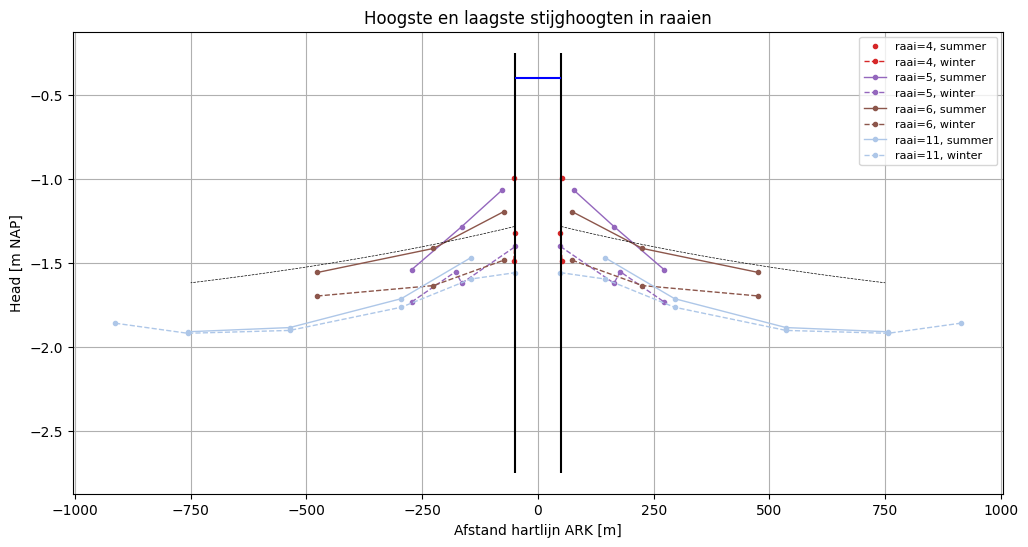

In [15]:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='joined')

# --- pd.DataFrame
pb_meta = pbxy.data

bARK = 50
kD, c = 1000., 1000.
lam = np.sqrt(kD * c)
y0, yb = -1.25, -1.95

x_ = np.linspace(bARK, 750, 71)
y_ = yb + (y0 - yb) * np.exp(-x_ / lam)
ax.plot(x_,  y_)
ax.plot(-x_, y_)

fig, ax = plt.subplots(figsize=(12,6))
ax.set_title("Hoogste en laagste stijghoogten in raaien")
ax.set_xlabel("Afstand hartlijn ARK [m]")
ax.set_ylabel("Head [m NAP]")

colors = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#7f7f7f',  # gray
    '#bcbd22',  # olive
    '#17becf',  # cyan
    '#aec7e8',  # light blue
    '#ffbb78',  # light orange
    '#98df8a',  # light green
]


for raai in np.unique(pb_meta['raai']):
    if raai not in [4, 5, 6, 11]:
        continue
    for WE in ['W', 'E']:
        for tcol in ['summer', 'winter']:
            mask = (pb_meta['raai'] == raai) & (pb_meta['WE'] == 'W') & (pb_meta[tcol] != 0)
            print(f"raai{raai}, WE={WE}, tcol={tcol}, sum(mask)={np.sum(mask)}")
            n = np.sum(mask)
            if n < 1:
                continue
            x = pb_meta.loc[mask, 'dist'].values
            y = pb_meta.loc[mask, tcol].values
            
            if WE == 'W':
                x = -x
                label=f"raai={raai}, {tcol}"                
            else:
                label=""                
                
            if tcol == 'summer':
                ls = '-'
            else:
                ls = '--'
                            
                
            if n == 1:
                ax.plot(x, y, 'o', ms=3, color=colors[raai - 1], label=label)
            else:
                if tcol == tcol[1]:
                    lw = 2
                else:
                    lw = 1
                ix = np.argsort(x)
                ax.plot(x[ix], y[ix], marker='o', ms=3, ls=ls, color=colors[raai - 1], lw=lw, label=label)
ax.grid()
ax.vlines([-bARK, bARK], ymin=-2.75, ymax=-0.25, colors=['k'])
ax.hlines([-0.4], xmin=-bARK, xmax=+bARK, colors='b')

ax.legend(fontsize=8)

ax.plot(-x_, y_, 'k--', lw=0.5)
ax.plot(+x_, y_, 'k--', lw=0.5)


x = np.linspace(50, 750, 101)


# Cross section model basid on best estimates of conductivities

In [193]:
reload(fdm3Blom)

<module 'tools.fdm.src.fdm3Blom' from '/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py'>

In [171]:
def get_analytical_props(gr, lagen, GHB, DRN):
    """Return aquifer props for analytical comparison.
    
    The hydraulic properties are obtained back from the
    model input data to verfiy the input's correctness.
    
    Returns
    -------
    kD: float
        transmissivity of the layers below the cover layer.
    c: float
        resistance of the cover layer (D/kv)
    cGHB: float
        median polder drainage resistance (adds to c in model)
        normally all values are the same unless changed in code.
        cGHB = dx / C [m/(d/m2])] = [d]        
    cDRN: float
        median resistance by the wellen (implemented by DRN) in the top of WVP1
        These DRNs leak parallel to GHB and, therefore reduce the overall
        vertical resistance in the model.
        normally all values are the same unless changed in code.
        cDRN = dx / C [m/(d/m2])] = [d]
    """
    deklaag = lagen['geo'] == 'Niewkoop'
    wvps = lagen['okLaag'] < lagen.loc[deklaag, 'okLaag'].values[0]
    sdps = lagen['okLaag'] >= lagen.loc[deklaag, 'okLaag'].values[0]

    kD = (lagen.loc[wvps, 'kh']  * lagen.loc[wvps, 'D']).sum()
    c = (lagen.loc[sdps, 'D'] / lagen.loc[sdps, 'kv']).sum().round()
    
    cGHB = np.median(gr.DX.ravel()[GHB['Ig']] / GHB['C']).round(1) 
    cDRN = np.median(gr.DX.ravel()[DRN['Ig']] / DRN['C']).round(1)
    return kD, c, cGHB, cDRN

# === Not too simple Xsec ARK model for testing ====

b_model = 10000. # --- Half width of model
b_wellen = 300. # Width the area next to the canal with the bulk of the wellen
b_kade = 10 # Width of the road next to the canal

# --- width, head, z sludge layer, z bottom
bARK, hARK, z_slib_ARK, zARK = 50., -0.4, -6.2, -6.7

ddw, zdw = 0.5, -10 # Thicknes of sheet piling
h_pold = -2.3 # Polder head levels

# --- Resisntaces
# --- Winter
# TODO: edit values
winter = False
if winter:
    c_ARK_slib, c_wellen, c_drainage = 10.0, 600., 200.
else: # zomer
    c_ARK_slib, c_wellen, c_drainage = 1.0,  500., 1.

# --- Definition of geological layers --> store in pd.DataFrame
columns = ['bkLaag', 'okLaag', 'kh', 'kv', 'geo', 'lith', 'fc']
data = np.array([[ -2.,  -2.5, 0.2, 0.02,  'Echteld',  'zk - k', 'darkgreen'],
                 [ -2.5, -6.0, 1.0, 0.003, 'Niewkoop', 'veen',   'brown'],
                 [ -6.0, -50., 15., 1.5,   'BX-DR',    'fz - gz','gold'],
                 [-50.,  -60., 0.2, 0.2,   'Waalre',   'klei',   'green'],
                 [-60., -160., 30., 10.,   'Peize',    'gz',     'yellow']])

data = np.array([[ -2.,  -2.5, 0.02, 0.02,  'Echteld',  'zk - k', 'darkgreen'],
                 [ -2.5, -6.0, 0.03, 0.003, 'Niewkoop', 'veen',   'brown'],
                 [ -6.0, -50., 15., 1.5,   'BX-DR',    'fz - gz','gold'],
                 [-50.,  -60., 0.2, 0.2,   'Waalre',   'klei',   'green'],
                 [-60., -160., 30., 30.,   'Peize',    'gz',     'yellow']])


lagen = pd.DataFrame(data, columns=columns)
lagen[columns[:4]] = lagen[columns[:4]].astype(float)

# --- Add additional property columns
lagen['D'] = lagen['bkLaag'] - lagen['okLaag']
lagen['kD'] = lagen['D'] * lagen['kh']
lagen['c']  = lagen['D'] / lagen['kv']

# --- The grid (combine specific z-coordinates, the layers and an overal refined enough grid)
z = np.unique(np.hstack((zdw, zARK, zARK + 0.5, lagen['bkLaag'], lagen['okLaag'], np.linspace(0, -160, 41))))[::-1]
z = z[z <= lagen.loc[0, 'bkLaag']]

# --- The x-grid
x1_ = bARK - np.logspace(0, np.log10(bARK), 10)      # --- inside the ARK
x2_ = np.logspace(np.log10(bARK), np.log10(b_model), 50)   # --- outside the ARK
x3_ = bARK + np.array([-1, 1, 2]) * ddw              # --- detail, side of canal

x = np.unique(np.hstack((0, 0.5, x1_, x2_, x3_, b_model - 1))) # --- combine all

gr = mfgrid.Grid(x, None, z)

# --- Matrix / cell properties
kh = gr.const(0)
kv = gr.const(0)

# --- Fill each geol layer
for lg in lagen.index:
    laag = lagen.loc[lg, :]
    mask = (gr.ZM > laag['okLaag']) & (gr.ZM < laag['bkLaag'])
    kh[mask] = laag['kh']
    kv[mask] = laag['kv']
       
# --- Special for the ARK water body and its sludge bottom 
mask_ARK = (gr.ZM > zARK) & (gr.XM < bARK) & (gr.XM > -bARK)
mask_ARK_slib = mask_ARK & (gr.ZM < z_slib_ARK)

# --- Layer blow sludge and bottom ARK
iz = np.searchsorted(-gr.z, -zARK - 0.5) + 1
mask_below_slib = (gr.ZM == gr.zm[iz]) & (gr.xm < bARK)

kh[mask_ARK] = 1000.
kv[mask_ARK] = 1000.
kv[mask_ARK_slib] = gr.DZ[mask_ARK_slib] / c_ARK_slib

# --- The sheet pilings
mask_damw = (gr.ZM > zdw) & (
                ((gr.XM > +bARK) & (gr.XM < bARK + ddw)) |
                ((gr.XM < -bARK) & (gr.XM > bARK - ddw))
)

# --- Boundary array (define fixed head heads and inactive cells)
IBOUND = gr.const(1, dtype=int)
IBOUND[mask_ARK]      = -1
IBOUND[mask_ARK_slib] = +1
IBOUND[mask_damw]     = 0


# --- Fixed flows (not now, all zero)
FQ = gr.const(0.)

# --- Starting heads
HI = gr.const(h_pold)
HI[mask_ARK] = hARK

# --- Test fixed heads only
# IBOUND[3:,0,-1] = -1
# HI[    3:,0,-1] = h_pold

# === Implement polder drainage using GHB outside ARK ===

# --- GHB boundary condition in top layer (polder)
echteld = lagen['geo'] == 'Echteld'
bk_ech = lagen.loc[echteld, 'bkLaag'].values[0]
iz = np.searchsorted(-gr.z, -bk_ech) - 1
mask_pold = (gr.ZM == gr.zm[iz]) & (gr.XM > bARK + b_kade)

# --- mask for top of first WVP under the polder
boxtel = lagen['geo'] == 'BX-DR'
bk_bx = lagen.loc[boxtel, 'bkLaag'].values[0]
iz = np.searchsorted(-gr.z, -bk_bx)
mask_boxt = (gr.ZM == gr.zm[iz]) & (gr.XM > bARK + b_kade)
iz, gr.zm[iz], mask_boxt

# --- Global cell indices of GHB locations
Ig_p = gr.NOD[mask_pold]

# --- Fill GHB 
GHB = np.zeros(len(Ig_p), dtype=fdm3Blom.Fdm3.dtypes['ghb'])
GHB['Ig'] = Ig_p
GHB['C'] = gr.DX.ravel()[Ig_p] / c_drainage     # --- convert overall drainage c to conductances
GHB['h'] = h_pold                                 # --- Polder level

# === Implement wellen (DRN in top of WVP1 over b_wellen outside ARK) ====

# --- DRN boundary just below Nieuwkoop cover layer
nwkp = lagen['geo'] == 'Niewkoop'
ok_NK = lagen.loc[nwkp, 'okLaag'].values[0]
iz = np.searchsorted(-gr.z, -ok_NK)
mask_wellen = (gr.ZM == gr.zm[iz]) & (gr.XM > bARK + b_kade) & (gr.XM < bARK + b_wellen)

# --- Global cell indices of DRN locations
xyz = np.vstack((gr.XM[mask_pold], gr.YM[mask_pold], gr.ZM[mask_pold])).T
Ig_w = gr.NOD[mask_wellen]

# --- Fill DRN 
DRN = np.zeros(len(Ig_w), dtype=fdm3Blom.Fdm3.dtypes['drn'])
DRN['Ig'] = Ig_w
DRN['C'] = gr.DX.ravel()[Ig_w] / c_wellen     # --- convert wellen drainage c to conductances
DRN['h'] = h_pold                             # --- Polder level

# --- Set up the FDM model
mdl = fdm3Blom.Fdm3(gr, K=(kh, kh, kv), S=None, IBOUND=IBOUND, HI=HI, FQ=FQ)
# --- Run it
out = mdl.simulate(tm=[1, 1.5], GHB=GHB, DRN=None)


No outer iterations needed.

===== Water balance of the entire model =====
Model grid = (46, 1, 64)

Sum over all nodal flows should be zero:
Total net in Q1     = 4.3586e-11 m3/d

Boundary components, these components should also add up zo zero:
Fixed flows         FQ   =           0.000 m3/d
Fixed heads         QFH  =           3.964 m3/d
GHB                Qghb =          -3.964 m3/d, flow from GHB cells.

Total water balance of this model
Q1 (internal)            =           0.000 m3/d, total internal flow
Q2 (boundaries)          =           0.000 m3/d, total from boundaries
===== end of water balance =====



## Plot the results of the model

/Users/Theo/Development/python/hydro_tools/tools/fdm/src/mfgrid.py:2020: UserWarning: This only works when all flow is within plane zx given by row
  warnings.warn("This only works when all flow is within plane zx given by row")


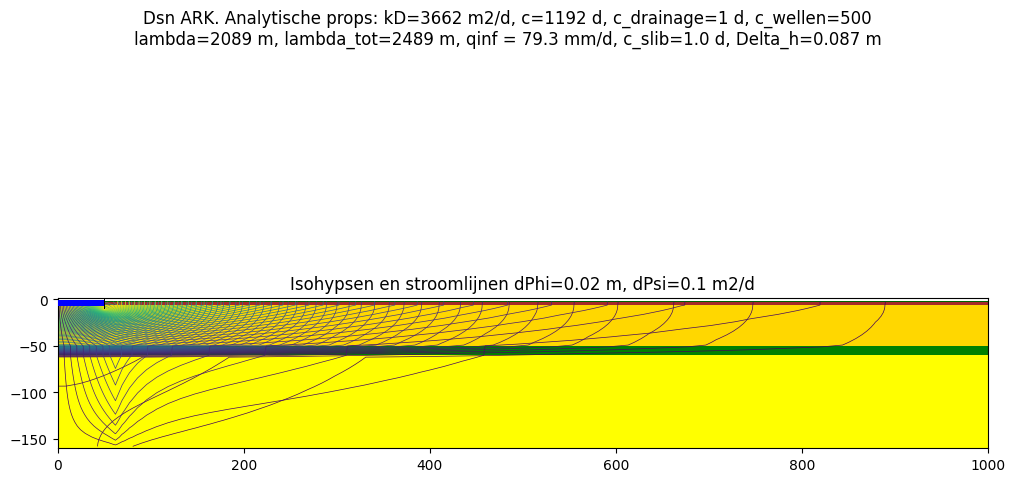

In [173]:
# --- Define funcion to fill x-section with colored patches
def get_patches(ax):
    for lg in lagen.index:
        rec = lagen.loc[lg]
        extent = (gr.x[0], gr.x[-1], rec['okLaag'], rec['bkLaag'])
        R = Rectangle((extent[0], extent[2]), extent[1] - extent[0], extent[3] - extent[2], fc=rec['fc'])
        ax.add_patch(R)
    ax.add_patch(Rectangle((0, zARK), bARK, hARK - zARK, fc='blue', zorder=4)) # ARK waterlichaam
    ax.add_patch(Rectangle((+bARK, zdw), +ddw, 0 - zdw, fc='k', zorder=4))     # Damwand
    ax.add_patch(Rectangle((-bARK, zdw), -ddw, 0 - zdw, fc='k', zorder=4))     # Damwand
    ax.add_patch(Rectangle((0, -zARK), 0, bARK, fc='gray', zorder=5)) # Kanaalbodem
    
# --- We want the head along the top of the first and second aquifers
itop_WVP1 = np.searchsorted(-gr.z, -lagen.loc[1, 'okLaag'])
itop_WVP2 = np.searchsorted(-gr.z, -lagen.loc[3, 'okLaag'])

# --- The masks for the top of the first and second aquifers
top_WVP1 = (gr.ZM == gr.zm[itop_WVP1])
top_WVP2 = (gr.ZM == gr.zm[itop_WVP2])


# --- step size of isohypses and stream function lines
dphi, dpsi = 0.02, 0.1
b_wellen = 300

# --- get levels for  contouring
phi_min, phi_max = np.round(np.nanmin(out['Phi']) * 100) / 100, np.round(np.nanmax(out['Phi']) * 100) / 100
phi_levels = np.arange(phi_min, phi_max + dphi, dphi)

psi = gr.psi_row(out['Qx'], row=0)
psi_min, psi_max = np.round(np.nanmin(psi) * 100) / 100, np.round(np.nanmax(psi) * 100) / 100
psi_levels = np.arange(psi_min, psi_max + dpsi, dpsi)

# --- View window
ylim = (None, 2)
xlim = (0, 1000)

# --- Plot of cross section
fig, ax = plt.subplots(figsize=(12, 7.5))

# --- Patch to show layers in colors
get_patches(ax)

# --- Contour heads and stream lines
Ch = ax.contour(gr.XM[:,0,:], gr.ZM[:,0,:], out['Phi'][:, 0, :], levels=phi_levels, linewidths=0.5)
Cp = ax.contour(gr.X[:,0,1:-1], gr.Z[:, 0, :-1], psi, levels=psi_levels, linewidths=0.5)

# --- Compute the analytical properties of this aquifer
kD, c, cGHB, cDRN = get_analytical_props(gr, lagen, GHB, DRN)
lam = np.sqrt(kD * c).round()
lam_tot = np.sqrt(kD * (c + cDRN)).round()

# --- Infiltration and resistance
c_ARK_slib = gr.DZ[mask_ARK_slib] / kv[mask_ARK_slib]
Qinf = out['Q'][mask_ARK]
qinf = Qinf.sum() / bARK
Delta_h = out['Phi'][mask_ARK_slib].mean() - out['Phi'][mask_below_slib].mean()

# --- Suptitle with details of this cross section.
supttl = (
    f"Dsn ARK. Analytische props: kD={kD:.0f} m2/d, c={c:.0f} d, c_drainage={cGHB:.0f} d, c_wellen={cDRN:.0f}\n" +
    f"lambda={lam:.0f} m, lambda_tot={lam_tot:.0f} m, qinf = {qinf * 1000:.1f} mm/d, c_slib={c_ARK_slib.mean():.1f} d, Delta_h={Delta_h:.3f} m"
)
fig.suptitle(supttl)
ax.set_title(f"Isohypsen en stroomlijnen dPhi={dphi} m, dPsi={dpsi} m2/d")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect(1)

plt.show()

## Plot head along the top of the first and second aquifers

raai4, WE=W, tcol=summer, sum(mask)=1
raai4, WE=W, tcol=winter, sum(mask)=2
raai4, WE=E, tcol=summer, sum(mask)=1
raai4, WE=E, tcol=winter, sum(mask)=2
raai5, WE=W, tcol=summer, sum(mask)=3
raai5, WE=W, tcol=winter, sum(mask)=4
raai5, WE=E, tcol=summer, sum(mask)=3
raai5, WE=E, tcol=winter, sum(mask)=4
raai6, WE=W, tcol=summer, sum(mask)=3
raai6, WE=W, tcol=winter, sum(mask)=3
raai6, WE=E, tcol=summer, sum(mask)=3
raai6, WE=E, tcol=winter, sum(mask)=3
raai11, WE=W, tcol=summer, sum(mask)=4
raai11, WE=W, tcol=winter, sum(mask)=6
raai11, WE=E, tcol=summer, sum(mask)=4
raai11, WE=E, tcol=winter, sum(mask)=6


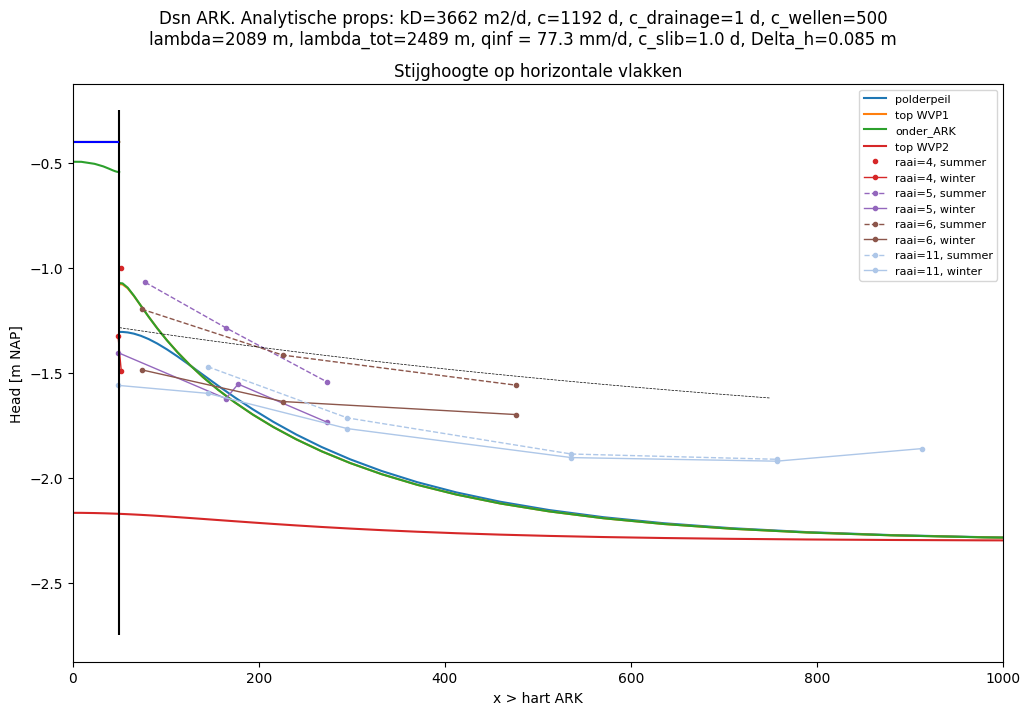

In [170]:
fig, ax = plt.subplots(figsize=(12, 7.5))

iz = np.searchsorted(-gr.z, -(zARK - 0.1)) - 1
onderARK = (gr.ZM == gr.zm[iz])

ax.plot(gr.xm,  out['Phi'][0,0,:],   label='polderpeil')
ax.plot(gr.xm, out['Phi'][top_WVP1], label='top WVP1')
ax.plot(gr.xm, out['Phi'][onderARK], label='onder_ARK')
ax.plot(gr.xm, out['Phi'][top_WVP2], label='top WVP2')

fig.suptitle(supttl)
ax.set_title("Stijghoogte op horizontale vlakken")
ax.set_xlabel('x > hart ARK')
ax.set_ylabel('Head [m NAP]')
ax.grid()
ax.set_xlim(xlim)
ax.legend()

# === Add heads measured in cross sections perpendicular to the ARK

for raai in np.unique(pb_meta['raai']):
    if raai not in [4, 5, 6, 11]:
        continue
    for WE in ['W', 'E']:
        for tcol in ['summer', 'winter']:
            mask = (pb_meta['raai'] == raai) & (pb_meta['WE'] == 'W') & (pb_meta[tcol] != 0)
            print(f"raai{raai}, WE={WE}, tcol={tcol}, sum(mask)={np.sum(mask)}")
            n = np.sum(mask)
            if n < 1:
                continue
            x = pb_meta.loc[mask, 'dist'].values
            y = pb_meta.loc[mask, tcol].values
            
            if WE == 'W':
                x = -x  # For now all on the positive x-axis
                label=f"raai={raai}, {tcol}"                
            else:
                label=""                
                
            if tcol == 'summer':
                ls = '--'
            else:
                ls = '-'
                            
                
            if n == 1:
                ax.plot(x, y, 'o', ms=3, color=colors[raai - 1], label=label)
            else:
                if tcol == tcol[1]:
                    lw = 2
                else:
                    lw = 1
                ix = np.argsort(x)
                ax.plot(x[ix], y[ix], marker='o', ms=3, ls=ls, color=colors[raai - 1], lw=lw, label=label)
ax.grid()
ax.vlines([-bARK, bARK], ymin=-2.75, ymax=-0.25, colors=['k'])
ax.hlines([-0.4], xmin=-bARK, xmax=+bARK, colors='b')

ax.legend(fontsize=8)

ax.plot(-x_, y_, 'k--', lw=0.5)
ax.plot(+x_, y_, 'k--', lw=0.5)




In [109]:
# Mean leak over b_wellen
mask_GHB = (gr.XM > bARK + b_kade) & (gr.XM < bARK + b_wellen) & (gr.ZM == gr.zm[0])
mask_DRN = (gr.XM > bARK + b_kade) & (gr.XM < bARK + b_wellen) & (gr.ZM == gr.zm[3])

q_sloten  = out['Q'][mask_GHB].sum()/gr.DX[mask_GHB].sum()
q_wellen  = out['Q'][mask_DRN].sum()/gr.DX[mask_DRN].sum()
print(f"q_sloten = {q_sloten*1000:.2f} mm/d, q_wellen={q_wellen*1000:.2f} mm/d")



q_sloten = -0.00 mm/d, q_wellen=-0.60 mm/d


In [163]:
iz = np.searchsorted(-gr.z, -(zARK - 0.1)) - 1
gr.zm[iz]

np.float64(-7.35)

In [118]:
Qdrn = out['DRN']['Q'].sum()
Qghb = out['GHB']['Q'].sum()
Qark = out['Q'][mask_ARK_slib].sum()
Qnet = Qdrn + Qghb + Qark

print(f"Qdrn = {Qdrn:.2f} m2/d Qghb = {Qghb:.2f} m2/d, Qark = {Qark:.2f} m2/d, Qnet = {Qnet:.2f} m2/d")

print(out['Phi'][mask_GHB].round(2))
print(out['Phi'][mask_DRN].round(2))


Qdrn = -0.17 m2/d Qghb = -2.79 m2/d, Qark = 2.97 m2/d, Qnet = 0.00 m2/d
[-1.11 -1.12 -1.13 -1.15 -1.17 -1.2  -1.23 -1.27 -1.31 -1.35 -1.4  -1.45
 -1.49 -1.54 -1.59 -1.64]
[-0.97 -1.01 -1.05 -1.09 -1.14 -1.18 -1.23 -1.27 -1.32 -1.37 -1.42 -1.46
 -1.51 -1.56 -1.61 -1.65]


# Distance wellen to ARK hartlijn

First get the meta data for the piezometers, which contains the row (raai) info.

Then define the y-range pertaining to each raai yielding a DataFrame with raai and y_mean, y_max and y_min
coordinates.

Then get the wellen in a DataFrame.

Add the column raai to it. For each point the raai is determined from the coordinate falling in a raai-range in the raaien DataFrame.

Pandas as a special trick for this, provide by chatgpt.

In [76]:
# --- Get the wellen
wellen_ = picklefrom(os.path.join(dirs.data, "wellen.pkl"))
wellen = pd.DataFrame(wellen_)
wellen.columns = ['x', 'y']
wellen.index.name = 'id'
wellen

# --- Add distance to ARK and xhit, yhit (perpendicular lines)
dist, pnts_hit = point_polyline_distance(wellen_, hartlijn_ARK)
wellen['dist'] = np.round(dist, 1)
wellen['xhit'] = pnts_hit.T[0].round(1)
wellen['yhit'] = pnts_hit.T[1].round(1)
wellen

Loaded <function basename at 0x103b9b9c0> <-- /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/wellen.pkl


,x,y,dist,xhit,yhit
id,,,,,
0,129398.0,476168.0,485.6,129876.8,476087.1
1,129405.0,476105.0,468.2,129866.7,476027.0
2,129602.0,476057.0,266.0,129864.3,476012.7
3,129598.0,476032.0,265.8,129860.1,475987.7
4,129570.0,475998.0,287.7,129853.7,475950.1
...,...,...,...,...,...
116,129701.0,474153.0,151.1,129552.1,474178.8
117,129759.0,474169.0,205.5,129556.5,474204.1
118,129837.0,474184.0,279.8,129561.3,474231.7


In [77]:
# --- get the meta data
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pb_meta = pbxy.data

# --- Generate the raaien DataFrame
Y = {}
# --- Get the existing raaien from the pd_meta DataFrame
for raai in np.unique(pb_meta['raai'].values):
    # --- the mean y for all piezometers belonging to a raai
    y = pb_meta.loc[pb_meta['raai']==raai, 'y'].mean()
    Y[int(raai)] = {'mean':float(y.mean().round())} 
    
# --- Add a virtual raai above and below the  existing ones
Y[ 0] = {'mean':Y[ 1]['mean'] + 250}
Y[14] = {'mean':Y[13]['mean'] - 250}

# --- Reorder the keys
for k in sorted(Y.keys()):
    Y[k] = Y.pop(k)
 
 # --- Get the min and max y for all raaien except the virtual ones
for k in list(Y.keys())[1:-1]:
    Y[k]['max'] =  (Y[k]['mean'] + Y[k-1]['mean']) / 2
    Y[k]['min']  = (Y[k]['mean'] + Y[k+1]['mean']) / 2

# --- Print the results except the virtual ones
for k in list(Y.keys())[1:-1]:
    # print(f"{k},{Y[k]['mean']},{Y[k]['max']},{Y[k]['min']}")
    pass
    
    
# --- Generate the DataFrame
raaien = pd.DataFrame(Y).T
raaien.index.name = "raai"

# --- Remove the virtual raaien
raaien = raaien.loc[raaien.index[1:-1]]
raaien

,mean,max,min
raai,,,
1,478867.0,478992.0,478163.0
2,477459.0,478163.0,476688.5
3,475918.0,476688.5,475642.5
4,475367.0,475642.5,475200.0
5,475033.0,475200.0,474588.5
6,474144.0,474588.5,473750.5
7,473357.0,473750.5,473105.5
8,472854.0,473105.5,472383.0
9,471912.0,472383.0,471028.0


In [78]:
import pandas as pd

# Create intervals [min, max)
intervals = pd.IntervalIndex.from_arrays(
    raaien['min'],
    raaien['max'],
    closed='left'
)

# Find the interval containing each y coordinate
wellen['raai'] = raaien.index[intervals.get_indexer(wellen['y'])]

# --- Sort wellen by 'raai' and then by 'dist'
wellen = wellen.sort_values(['raai', 'dist'])

# --- Redifine the index
wellen.index = np.arange(len(wellen))
wellen

pickleto(wellen, os.path.join(dirs.data, "wellen_df.pkl"))

Pickled <function basename at 0x103b9b9c0> --> /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/wellen_df.pkl


In [ ]:
nwkp = lagen['geo'] == 'Niewkoop'
ok_NK = lagen.loc[nwkp, 'okLaag'].values[0]
iz = np.searchsorted(-gr.z, -ok_NK)
b_wellen = 300. # Width the area next to the canal with the bulk of the wellen
mask_wellen = (gr.ZM == gr.zm[iz]) & (gr.XM > bARK + 10) & (gr.XM < bARK + b_wellen)

gr.XM[mask_wellen]

len(wellen)

121

array([-6.1, -6.1, -6.1, -6.1, -6.1, -6.1, -6.1, -6.1, -6.1, -6.1, -6.1,
       -6.1, -6.1, -6.1, -6.1, -6.1, -6.1, -6.1, -6.1])

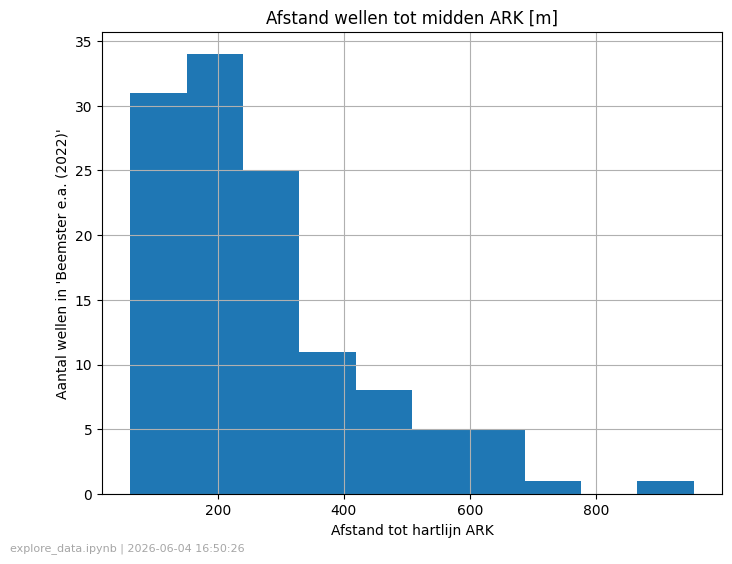

In [104]:
fig, ax = plt.subplots(figsize=(8, 6))
wellen.hist('dist', ax=ax)
ax.set_title("Afstand wellen tot midden ARK [m]")
ax.set_xlabel("Afstand tot hartlijn ARK")
ax.set_ylabel("Aantal wellen in 'Beemster e.a. (2022)'")
ax.grid(True)
logo(fig, NOTEBOOK_NAME)
# fig.savefig(os.path.join(dirs.images, "hist_afstand_wellen_tot_ARK.pdf"))

Ig = gr.NOD[mask_wellen]
gr.ZM[mask_wellen]
